### 1. Data Aggregation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the file mapping
country_files = {
    'Ethiopia': '../data/ethiopia_clean.csv',
    'Sudan': '../data/sudan_clean.csv',
    'Kenya': '../data/kenya_clean.csv',
    'Nigeria': '../data/nigeria_clean.csv',
    'Tanzania': '../data/tanzania_clean.csv'
}

# Concatenate into one DataFrame
all_data = []
for name, path in country_files.items():
    df = pd.read_csv(path)
    df['Country'] = name
    all_data.append(df)

df_master = pd.concat(all_data, ignore_index=True)
df_master['Date'] = pd.to_datetime(df_master['Date'])

# Create a 'Monthly' column for a smoother line chart
df_master['Month'] = df_master['Date'].dt.to_period('M').dt.to_timestamp()

### 2. Temperature Trend Comparison ($T2M$)

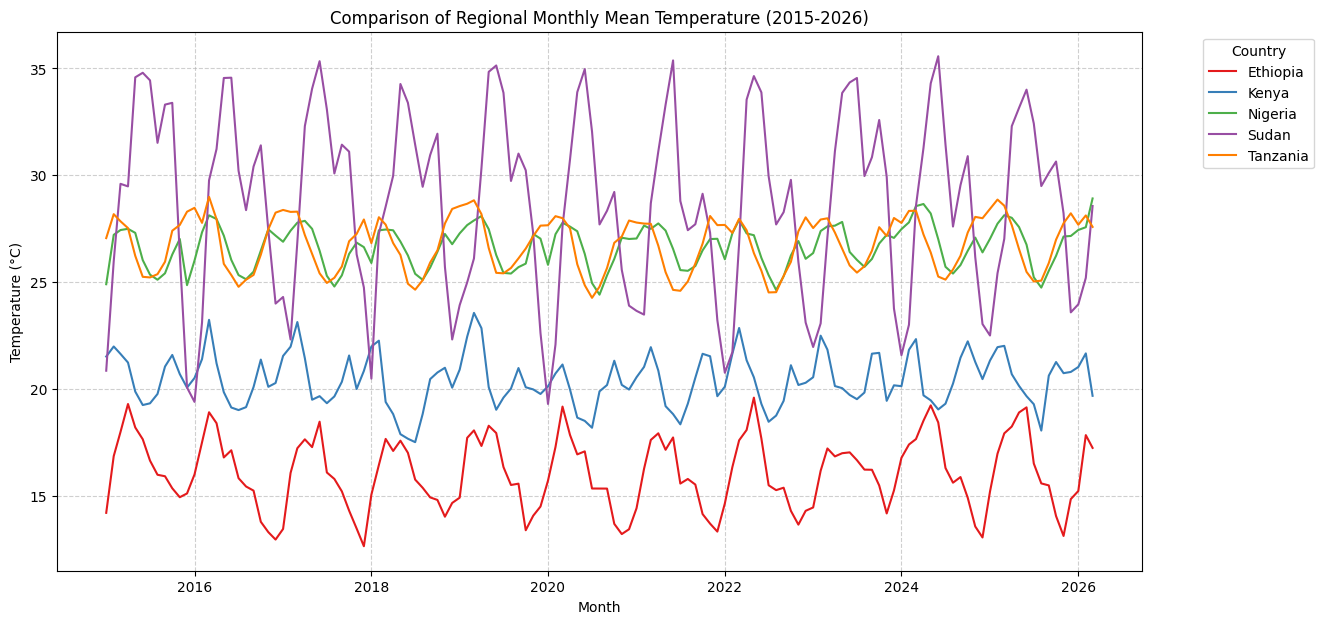

T2M Temperature Statistics by Country:
           mean  median   std
Country                      
Ethiopia  16.07   16.04  1.90
Kenya     20.43   20.36  1.44
Nigeria   26.66   26.82  1.12
Sudan     28.76   29.16  4.68
Tanzania  26.80   26.99  1.33


In [ ]:
monthly_t2m = df_master.groupby(['Month', 'Country'])['T2M'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_t2m, x='Month', y='T2M', hue='Country', palette='Set1')
plt.title('Comparison of Regional Monthly Mean Temperature (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Statistical Summary Table
t2m_stats = df_master.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).round(2)
print("T2M Temperature Statistics by Country:")
print(t2m_stats)


### 3. Precipitation Variability Comparison ($PRECTOTCORR$)
* Boxplots are the best way to visualize "Climate Volatility." The height of the box and the length of the whiskers tell the story of flood vs. drought risk.Pythonplt.figure(figsize=(12, 6))

C:\Users\Helen\AppData\Local\Temp\ipykernel_11652\548765193.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='Country', y='PRECTOTCORR', palette='Spectral')


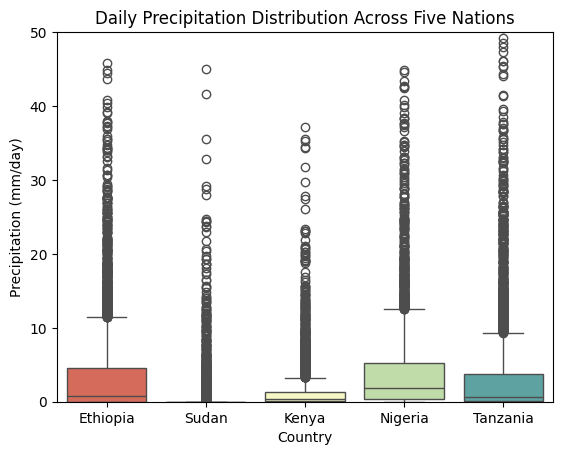

Precipitation Statistics by Country:
          mean  median   std
Country                     
Ethiopia  3.64    0.82  6.29
Kenya     1.47    0.38  3.18
Nigeria   4.21    1.84  7.27
Sudan     0.64    0.00  3.06
Tanzania  3.74    0.64  8.00


In [3]:

sns.boxplot(data=df_master, x='Country', y='PRECTOTCORR', palette='Spectral')
plt.title('Daily Precipitation Distribution Across Five Nations')
plt.ylabel('Precipitation (mm/day)')
plt.ylim(0, 50) # Cutting the axis helps visibility, but keep an eye on outliers!
plt.show()

# Statistical Summary Table
precip_stats = df_master.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).round(2)
print("Precipitation Statistics by Country:")
print(precip_stats)